data loading and understanding

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
print("Shape (rows, columns):", df.shape)
print("\nColumn names:\n", list(df.columns))
print("\nData types:\n")
df.info()

Shape (rows, columns): (7043, 21)

Column names:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-nul

In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
print("Target variable: Churn")
print(df["Churn"].value_counts())

Target variable: Churn
Churn
No     5174
Yes    1869
Name: count, dtype: int64


TASK 2:DATA PREPROCESSING

In [10]:
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nTotalCharges data type:", df["TotalCharges"].dtype)

Missing values per column:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows: 0

TotalCharges data type: object


In [11]:
# TotalCharges is stored as text because some values are blank spaces
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing TotalCharges after conversion:", df["TotalCharges"].isnull().sum())
df[df["TotalCharges"].isnull()][["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

Missing TotalCharges after conversion: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [12]:
# These customers have tenure = 0 (brand new, never billed), so TotalCharges = 0 makes sense
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# customerID is only an identifier, so it is useless for prediction
df = df.drop("customerID", axis=1)

print("Missing values now:", df.isnull().sum().sum())
print("New shape:", df.shape)
df.dtypes

Missing values now: 0
New shape: (7043, 20)


,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


exploratory data analysis

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


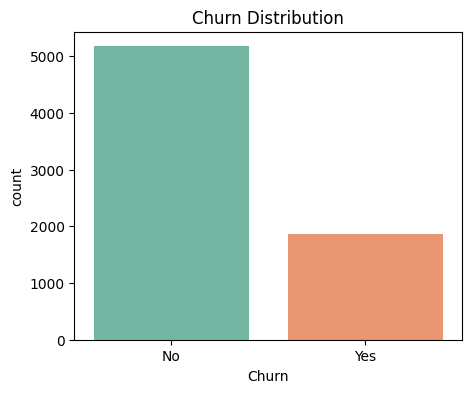

In [13]:
print(df["Churn"].value_counts(normalize=True) * 100)

plt.figure(figsize=(5,4))
sns.countplot(x="Churn", data=df, palette="Set2")
plt.title("Churn Distribution")
plt.show()

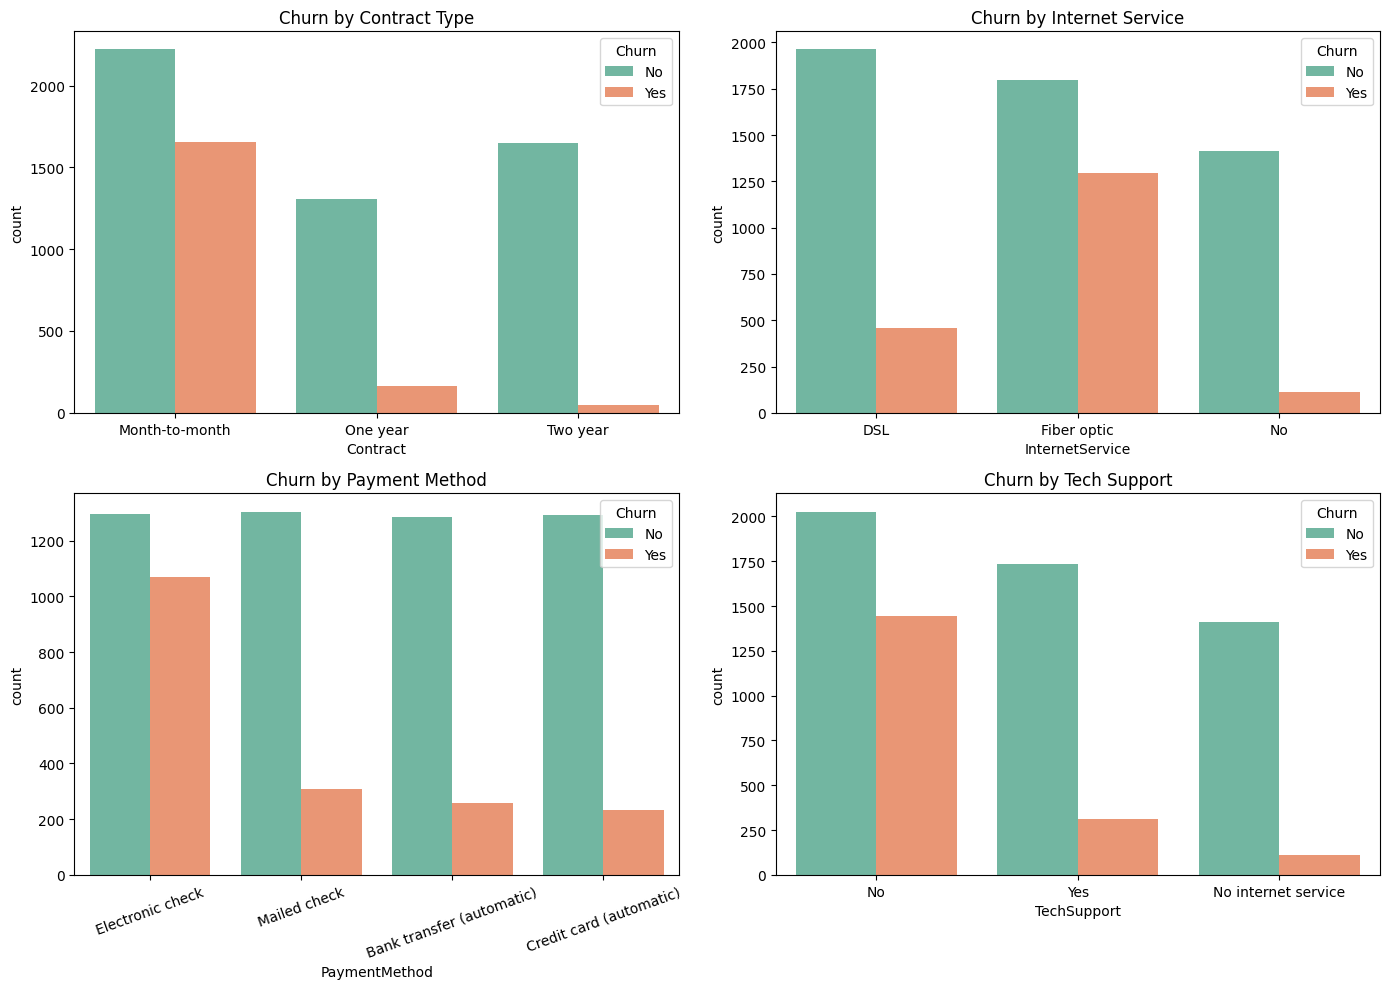

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(x="Contract", hue="Churn", data=df, ax=axes[0,0], palette="Set2")
axes[0,0].set_title("Churn by Contract Type")

sns.countplot(x="InternetService", hue="Churn", data=df, ax=axes[0,1], palette="Set2")
axes[0,1].set_title("Churn by Internet Service")

sns.countplot(x="PaymentMethod", hue="Churn", data=df, ax=axes[1,0], palette="Set2")
axes[1,0].set_title("Churn by Payment Method")
axes[1,0].tick_params(axis="x", rotation=20)

sns.countplot(x="TechSupport", hue="Churn", data=df, ax=axes[1,1], palette="Set2")
axes[1,1].set_title("Churn by Tech Support")

plt.tight_layout()
plt.show()

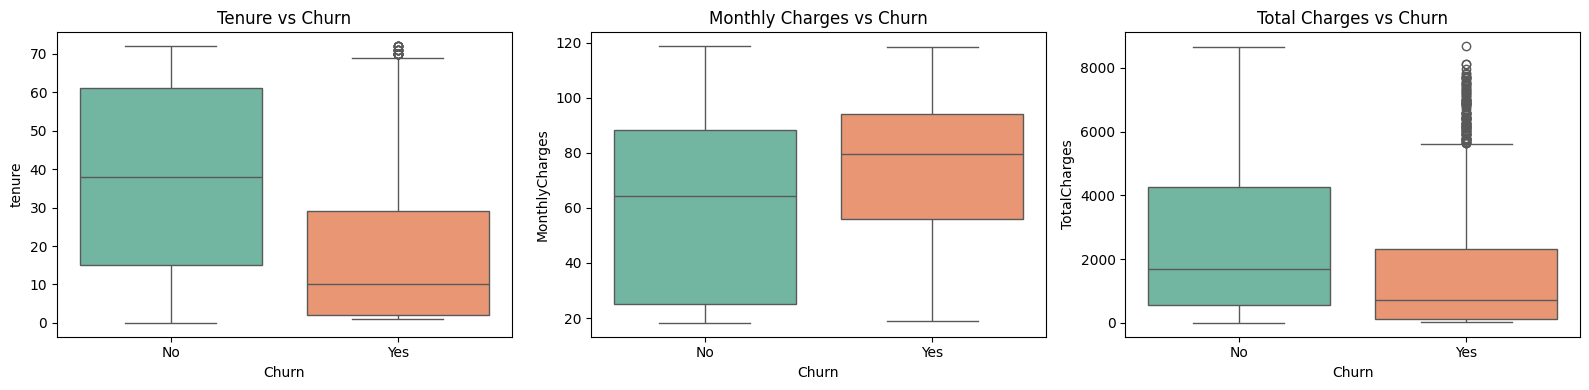

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(x="Churn", y="tenure", data=df, ax=axes[0], palette="Set2")
axes[0].set_title("Tenure vs Churn")

sns.boxplot(x="Churn", y="MonthlyCharges", data=df, ax=axes[1], palette="Set2")
axes[1].set_title("Monthly Charges vs Churn")

sns.boxplot(x="Churn", y="TotalCharges", data=df, ax=axes[2], palette="Set2")
axes[2].set_title("Total Charges vs Churn")

plt.tight_layout()
plt.show()

In [16]:
print("Churn rate (%) by Contract:")
print((df.groupby("Contract")["Churn"].apply(lambda x: (x=="Yes").mean()*100)).round(2))

print("\nAverage values by Churn:")
df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean().round(2)

Churn rate (%) by Contract:
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64

Average values by Churn:


,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.57,61.27,2549.91
Yes,17.98,74.44,1531.80


Feature Engineering and Encoding

In [17]:
def add_features(d):
    d = d.copy()
    # Group tenure into ranges
    d["tenure_group"] = pd.cut(d["tenure"], bins=[-1, 12, 24, 48, 72],
                               labels=["0-12", "13-24", "25-48", "49-72"]).astype(str)
    # Count how many extra services a customer uses
    services = ["PhoneService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
                "TechSupport", "StreamingTV", "StreamingMovies"]
    d["num_services"] = sum((d[c] == "Yes").astype(int) for c in services)
    return d

df_fe = add_features(df)
df_fe[["tenure", "tenure_group", "num_services"]].head()

,tenure,tenure_group,num_services
0,1,0-12,1
1,34,25-48,3
2,2,0-12,3
3,45,25-48,3
4,2,0-12,1


In [18]:
# Target: convert Yes/No into 1/0
y = df_fe["Churn"].map({"No": 0, "Yes": 1})

# Input features
X_raw = df_fe.drop("Churn", axis=1)

# One-hot encoding for all text columns
X = pd.get_dummies(X_raw, drop_first=True).astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (7043, 34)
y shape: (7043,)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,num_services,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_13-24,tenure_group_25-48,tenure_group_49-72
0,0.0,1.0,29.85,29.85,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,34.0,56.95,1889.50,3.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.0,2.0,53.85,108.15,3.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,45.0,42.30,1840.75,3.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,2.0,70.70,151.65,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


Training and Testing

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("\nChurn rate in train:", round(y_train.mean(), 3))
print("Churn rate in test:", round(y_test.mean(), 3))

Training set: (5634, 34)
Testing set: (1409, 34)

Churn rate in train: 0.265
Churn rate in test: 0.265


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Logistic Regression needs scaled features, so we use a pipeline (scaler + model)
log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

rf_model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)

log_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

print("Both models trained successfully")

Both models trained successfully


Model Evaluation

In [21]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

models = {"Logistic Regression": log_model, "Random Forest": rf_model}
results = []

for name, model in models.items():
    pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1-Score": f1_score(y_test, pred)
    })
    print("=====", name, "=====")
    print(classification_report(y_test, pred, target_names=["No Churn", "Churn"]))

results_df = pd.DataFrame(results).round(3)
results_df

===== Logistic Regression =====
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

===== Random Forest =====
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1035
       Churn       0.67      0.48      0.56       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.798,0.650,0.521,0.579
1,Random Forest,0.799,0.668,0.484,0.561


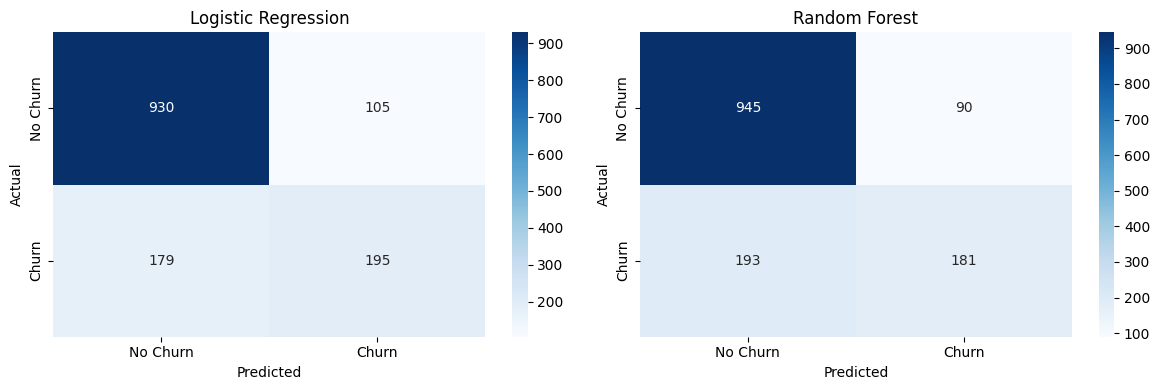

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

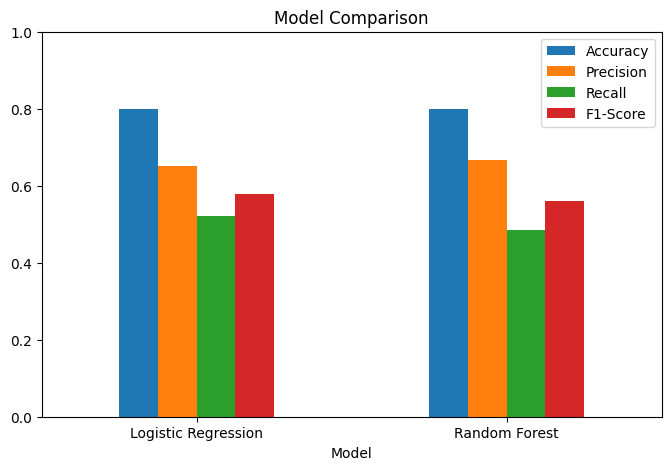

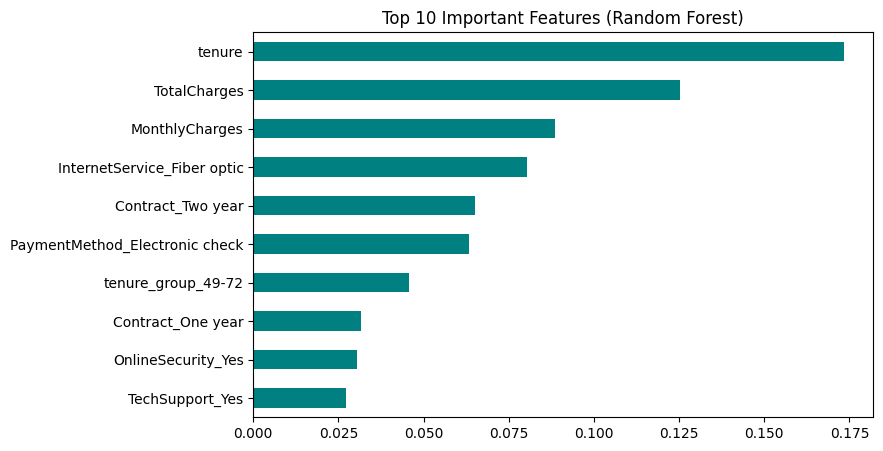

In [23]:
results_df.set_index("Model").plot(kind="bar", figsize=(8, 5), rot=0)
plt.title("Model Comparison")
plt.ylim(0, 1)
plt.show()

importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(8, 5))
importances.sort_values().plot(kind="barh", color="teal")
plt.title("Top 10 Important Features (Random Forest)")
plt.show()

Application / Prediction

In [24]:
# Pick the model with the higher F1-score automatically
best_name = results_df.sort_values("F1-Score", ascending=False).iloc[0]["Model"]
final_model = models[best_name]
print("Final selected model:", best_name)

Final selected model: Logistic Regression


In [25]:
def predict_churn(customer, model=final_model):
    c = pd.DataFrame([customer])
    c = add_features(c)
    c = pd.get_dummies(c).astype(float)
    c = c.reindex(columns=X.columns, fill_value=0)   # match training columns
    pred = model.predict(c)[0]
    prob = model.predict_proba(c)[0][1]
    label = "CHURN" if pred == 1 else "NO CHURN"
    print(f"Prediction: {label}  (churn probability: {prob*100:.1f}%)")

In [26]:
# Customer 1: new, month-to-month, fiber, high bill, no support
customer1 = {
    "gender": "Female", "SeniorCitizen": 0, "Partner": "No", "Dependents": "No",
    "tenure": 2, "PhoneService": "Yes", "MultipleLines": "No",
    "InternetService": "Fiber optic", "OnlineSecurity": "No", "OnlineBackup": "No",
    "DeviceProtection": "No", "TechSupport": "No", "StreamingTV": "Yes",
    "StreamingMovies": "Yes", "Contract": "Month-to-month", "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check", "MonthlyCharges": 95.5, "TotalCharges": 191.0
}

# Customer 2: long-term, 2-year contract, uses support
customer2 = {
    "gender": "Male", "SeniorCitizen": 0, "Partner": "Yes", "Dependents": "Yes",
    "tenure": 60, "PhoneService": "Yes", "MultipleLines": "Yes",
    "InternetService": "DSL", "OnlineSecurity": "Yes", "OnlineBackup": "Yes",
    "DeviceProtection": "Yes", "TechSupport": "Yes", "StreamingTV": "No",
    "StreamingMovies": "No", "Contract": "Two year", "PaperlessBilling": "No",
    "PaymentMethod": "Credit card (automatic)", "MonthlyCharges": 65.0, "TotalCharges": 3900.0
}

print("Customer 1:"); predict_churn(customer1)
print("Customer 2:"); predict_churn(customer2)

Customer 1:
Prediction: CHURN  (churn probability: 78.9%)
Customer 2:
Prediction: NO CHURN  (churn probability: 0.9%)
